In [1]:

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import math
from datetime import datetime
from PIL import Image
from skimage import color
from skimage import io
import cv2
import height_calculator as hc

# Load data

In [2]:
ls 20220723/pass_97_b_172515_ffc/ #

frame_c301_20220723_172435_sky_bluesky.png
frame_c301_20220723_172436_sky_bluesky.png
frame_c301_20220723_172437_sky_bluesky.png
frame_c301_20220723_172438_sky_bluesky.png
frame_c301_20220723_172439_sky_bluesky.png
frame_c301_20220723_172440_sky_bluesky.png
frame_c301_20220723_172441_sky_bluesky.png
frame_c301_20220723_172442_sky_bluesky.png
frame_c301_20220723_172443_sky_bluesky.png
frame_c301_20220723_172444_sky_bluesky.png
frame_c301_20220723_172445_sky_bluesky.png
frame_c301_20220723_172446_sky_bluesky.png
frame_c301_20220723_172447_sky_bluesky.png
frame_c301_20220723_172448_sky_bluesky.png
frame_c301_20220723_172449_sky_bluesky.png
frame_c301_20220723_172450_sky_bluesky.png
frame_c301_20220723_172451_sky_bluesky.png
frame_c301_20220723_172452_sky_bluesky.png
frame_c301_20220723_172453_sky_bluesky.png
frame_c301_20220723_172454_sky_bluesky.png
frame_c301_20220723_172455_sky_bluesky.png
frame_c301_20220723_172456_sky_bluesky.png
frame_c301_20220723_172457_sky_bluesky.png
frame_c301_

In [3]:
frame='frame_c301_20220723_172439_sky_bluesky.png'
file_name = '20220723/pass_97_b_172515_ffc/'+frame
dataset = xr.open_dataset('core_faam_20220723_v005_r0_c301_1hz.nc')
cloud_passes = pd.read_csv('FAAM_cloudpass_info.csv')
ffc=True
rfc=False

In [4]:
print(file_name)

20220723/pass_97_b_172515_ffc/frame_c301_20220723_172439_sky_bluesky.png


In [5]:
ls 20220723/pass_97_b_172515_ffc/frame_c301_20220723_172455_sky_bluesky.png


20220723/pass_97_b_172515_ffc/frame_c301_20220723_172455_sky_bluesky.png


# Functions to extract air craft data, cloud position and distance camera to cloud

In [6]:
def extract_pass_number(file_name):
    filepath_parts = file_name.split('/')
    pass_number= filepath_parts[1].split('_')[1]
    return pass_number

In [7]:
def extract_timestamp_from_filename(filepath):
    filepath_parts = filepath.split('/')
    filename_parts = filepath_parts[2].split('_')
    camera= filepath_parts[1].split('_')[3]
    date = filename_parts[2]
    times = filename_parts[3]
    full_timestamp = pd.to_datetime(date+'_'+times, format="%Y%m%d_%H%M%S")
    return [camera, full_timestamp] 

In [8]:
# Define a function to find the closest roll_time and get the corresponding roll_angle
def get_closest_roll_angle(aircraft_df, frame_time):
    # Calculate the absolute difference between frame_time and all roll_times
    diffs = abs(aircraft_df['times'] - frame_time)
    # Find the index of the minimum difference
    min_diff_index = diffs.idxmin()
    # Return the corresponding roll_angle
    return aircraft_df.loc[min_diff_index]

In [9]:
def extract_variables(dataset):
    roll = dataset['ROLL_GIN']
    lat = dataset['LAT_GIN'].data[:]
    lon = dataset['LON_GIN'].data[:]
    pitch = dataset['PTCH_GIN'].data[:]
    alt = dataset['PALT_RVS'].data[:]
    veln = dataset['VELN_GIN'].data[:]
    vele = dataset['VELE_GIN'].data[:]
    roll_times = roll.Time
    roll_angle = roll.data[:]
    roll_times_pd = pd.to_datetime(roll_times.data)
    aircraft_df = pd.DataFrame({'times': roll_times_pd, 'lat': lat, 'lon' : lon, 'pitch' : pitch, 'alt': alt, 'roll_angles': roll_angle, 'veln': veln, 'vele': vele})
    return aircraft_df


In [10]:
def extract_cloud_pass_info(cloud_passes, pass_number):
    pass_info = cloud_passes.loc[int(pass_number)-1]
    cloud_lat1 = pass_info['start_lat']
    cloud_lon1 = pass_info['start_lon']
    cloud_lat2 = pass_info['end_lat']
    cloud_lon2 = pass_info['end_lon']
    start_time = datetime.strptime(pass_info['start_datetime'], '%Y-%m-%d %H:%M:%S')
    end_time = datetime.strptime(pass_info['end_datetime'], '%Y-%m-%d %H:%M:%S')
    return [cloud_lat1, cloud_lon1, cloud_lat2, cloud_lon2, start_time, end_time]

In [11]:
def haversine( lon1, lat1, lon2, lat2, alt):
    R = 6371e3 + alt # radius of Earth in metres
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = phi2-phi1
    
    lambda1 = math.radians(lon1)
    lambda2 = math.radians(lon2)
    dlambda = lambda2-lambda1

    a = math.sin(dphi/2) * math.sin(dphi/2) + math.cos(phi1) * math.cos(phi1) * math.sin(dlambda/2) * math.sin(dlambda/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    d = R * c
    
    return d

In [12]:
# Get the distance
#extract info
camera, timestamp = extract_timestamp_from_filename(file_name)
pass_number = extract_pass_number(file_name)
aircraft_df = extract_variables(dataset)
aircraft_position = get_closest_roll_angle(aircraft_df, timestamp)
pass_info = extract_cloud_pass_info(cloud_passes, pass_number)
pass_lat1, pass_lon1, pass_lat2, pass_lon2, start_time, end_time = pass_info
# get mid pass time and thus the aircraft position at that time
mid_pass_time = start_time + (end_time - start_time)/2
aircraft_pass_position = get_closest_roll_angle(aircraft_df, mid_pass_time)

# Check roll
if abs(aircraft_position['roll_angles']) > 15:
    print('Aircraft not level')
    print(aircraft_position['roll_angles'])
    print(aircraft_position['roll_angles'])
elif abs(aircraft_pass_position['roll_angles']) > 10:
    print('Aircraft was not level')
    print(aircraft_pass_position['roll_angles'])
        



In [13]:
D1 = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_lon1, pass_lat1, aircraft_pass_position['alt'])
D2 = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_lon2, pass_lat2, aircraft_pass_position['alt'])
D = (D1 + D2)/2

In [14]:
print('Distance to cloud start: ', D1, 'm')
print('Distance to cloud end: ', D2, 'm')
print('Distance to cloud mid: ', D, 'm')

Distance to cloud start:  427.66927773021445 m
Distance to cloud end:  5787.917247708222 m
Distance to cloud mid:  3107.793262719218 m


In [15]:
print('Using Distance to cloud mid: ', + D)
distance_override=False
pass_portion = 0.8
if distance_override:
    D = (D1 + D2) * pass_portion
    print('Overriding distance to: ', D)

Using Distance to cloud mid:  3107.793262719218


In [16]:
aircraft_pass_position

times          2022-07-23 17:24:57
lat                      34.012169
lon                    -107.178665
pitch                     5.819678
alt                    5158.435059
roll_angles               1.491543
veln                    127.561592
vele                    -68.717651
Name: 14293, dtype: object

# find pixel height

In [51]:
# Set Constants for edge detection:
# How white vs grey (this might need to be set by trial and error)    
WHITENESS_THRESHOLD = 175
# line thickness of box
THICKNESS = 10
# The part of every photo is just ground set to 0 if whole photo is cloud
NOTSKY = 325

In [52]:


img = io.imread(file_name)
img_grey = color.rgb2gray(img)

In [53]:
img_grey = cv2.bilateralFilter(img, 18, 100, 100)
mask = np.all(img > WHITENESS_THRESHOLD, axis=-1)
img_grey[~mask] = 0
cv_grey = cv2.GaussianBlur(img_grey.astype(np.uint8) * 255, (7, 7), 0)
edges = cv2.Canny(cv_grey, 0, 120)
edges[NOTSKY::,:]=0
edges[:,0:20]=0
edges[:,-15::]=0
edges[0:20,:]=0
# Find contours and sort by area
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, 
                                   cv2.CHAIN_APPROX_SIMPLE)

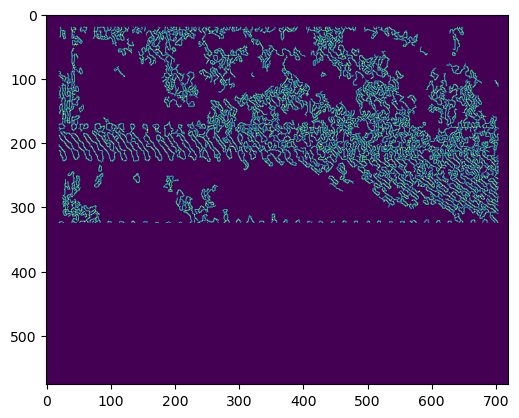

In [54]:
plt.imshow(edges)

In [55]:
# Draw the contours on the original image
thickness = 8  # Adjust this value to control the thickness of the drawn contours
edge_image = cv2.imread(file_name).copy()
cv2.drawContours(edge_image, contours, -1, (0, 255, 0), thickness)

array([[[29, 21, 43],
        [17,  9, 31],
        [41, 10, 40],
        ...,
        [48, 31, 18],
        [38, 21,  3],
        [42, 25,  7]],

       [[22, 14, 36],
        [26, 18, 40],
        [47, 16, 46],
        ...,
        [47, 30, 17],
        [49, 32, 14],
        [39, 22,  4]],

       [[39,  7, 26],
        [49, 17, 36],
        [63, 22, 40],
        ...,
        [50, 35, 22],
        [64, 33, 22],
        [46, 15,  4]],

       ...,

       [[32, 18, 37],
        [26, 12, 31],
        [29, 25, 35],
        ...,
        [26, 22, 18],
        [12, 18, 13],
        [18, 24, 19]],

       [[13, 10, 32],
        [17, 14, 36],
        [26, 35, 50],
        ...,
        [20, 17, 16],
        [11, 21, 18],
        [14, 24, 21]],

       [[20, 17, 39],
        [ 8,  5, 27],
        [24, 33, 48],
        ...,
        [20, 17, 16],
        [15, 25, 22],
        [15, 25, 22]]], dtype=uint8)

In [41]:
cv2.imwrite('cloud_edge.png', edge_image)
cloud_edge=Image.open('cloud_edge.png')

photo is 720 pixels wide plane nose looks off center could use 360 otr 380 in line with nose?

In [47]:
x_target = 380
found_points = []
search_range = 300



def find_intersection(x_target):
    for contour in contours:
        for point in contour:
            x, y = point[0]
            if x == x_target:
                return (x, y)
    return None


# Search for intersection
for offset in range(search_range):
    # Check current x_target
    result = find_intersection(x_target)
    if result:
        found_points.append(result)
        break

    # Check x_target + offset
    result = find_intersection(x_target + offset)
    if result:
        found_points.append(result)
        x_target += offset
        break

    # Check x_target - offset
    result = find_intersection(x_target - offset)
    if result:
        found_points.append(result)
        x_target -= offset
        break

if found_points:
    x, y = found_points[0]
    print(f"Contour intersects x={x_target} at y={y}")
else:
    print(f"No contours intersect within the search range of {search_range} pixels from x={x_target}")


Contour intersects x=225 at y=319


In [48]:
pixel_height = 576- y


In [49]:
pixel_height_override = False
yo = 130
if pixel_height_override:
    pixel_height = 576-yo
    print('Overriding pixel height to: ', pixel_height)

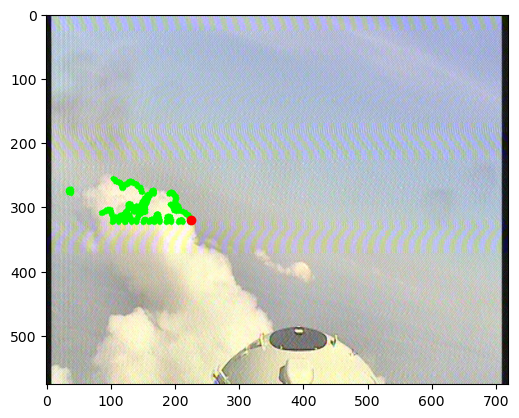

In [50]:
plt.imshow(cloud_edge)
plt.plot(x_target, 576-pixel_height, 'ro')

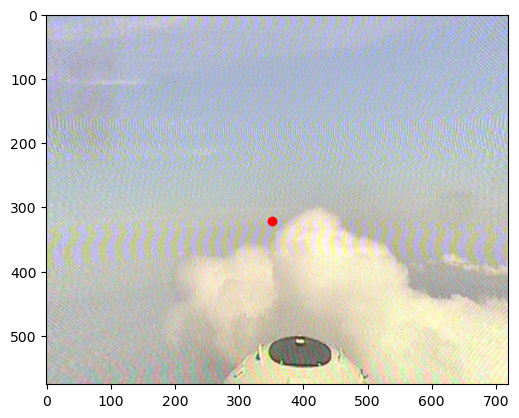

In [27]:
image = cv2.imread(file_name)
# Define your camera parameters
focal_length = 12.0  # In mm (from your lens specs)
sensor_width = 6.4  # Sensor width in mm
sensor_height = 4.8  # Sensor height in mm
image_width = image.shape[1]
image_height = image.shape[0]

# Calculate fx and fy (focal lengths in pixel units)
fx = (focal_length / sensor_width) * image_width
fy = (focal_length / sensor_height) * image_height

# Camera matrix (intrinsics matrix)
camera_matrix = np.array([[fx, 0, image_width / 2],
                          [0, fy, image_height / 2],
                          [0, 0, 1]])

# Approximate distortion coefficients (assumed for barrel distortion)
# These can be fine-tuned based on your lens and testing
# k1, k2 represent radial distortion coefficients
# p1, p2 are tangential distortion coefficients (set to 0 for simplicity)
distortion_coefficients = np.array([-2, -0.3, -0.05, 0, 0])

# Step 4: Undistort the image
undistorted_image = cv2.undistort(image, camera_matrix, distortion_coefficients)
cv2.imwrite('undistorted_image.jpg', undistorted_image)
cloud_edge=Image.open('undistorted_image.jpg')
plt.imshow(cloud_edge)
plt.plot(x_target, 576-pixel_height, 'ro')

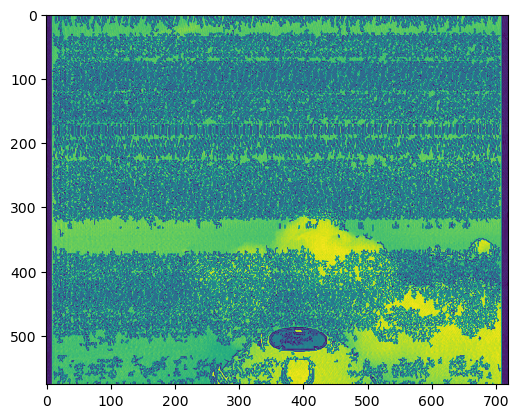

In [28]:

# Load your image
image = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

# Detect edges using Canny Edge Detection (or another method)
edges = cv2.Canny(image, 50, 150)

# Find contours (or lines) in the edge-detected image
contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Draw detected contours on a copy of the original image
image_with_contours = image.copy()
cv2.drawContours(image_with_contours, contours, -1, (0, 255, 0), 1)
plt.imshow(image_with_contours)

# find cloud height

[LTC3244/20](https://www.sourcesecurity.com/datasheets/bosch-ltc-3214-20/co-289-ga/FixedLenses.pdf)



In [29]:
pixel_height-576/2

-33.0

In [55]:
calculator=hc.CloudHeightCalculator(-33,D,aircraft_pass_position['pitch']-3)
height_corrected =calculator.calculate_height()
print(height_corrected)

-64.33250148606096


In [56]:
x=D*math.tan(math.radians(aircraft_pass_position['pitch']-3))

In [57]:
x

153.10542813044236

In [58]:
cloud_top_height = height_corrected + aircraft_position['alt']+x

In [59]:
print('the estimated cloud top height is: ', cloud_top_height)

the estimated cloud top height is:  5248.427223519381


In [60]:
print('the pass height was: ', aircraft_pass_position['alt'])

the pass height was:  5158.435


In [81]:
pass_diff=cloud_top_height-aircraft_pass_position['alt']

Text(0.5, 1.0, 'Pass 97, Timestamp: 2022-07-23 17:24:55.\n Estimated plane flew 89m below cloud top')

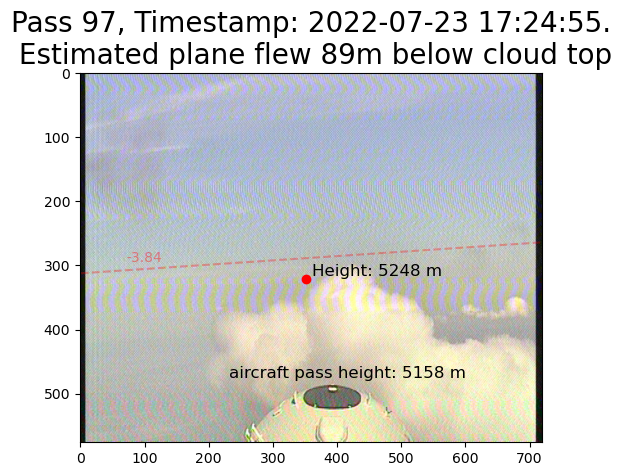

In [94]:
img = io.imread(file_name)
plt.imshow(img)
plt.plot(x_target, 576-pixel_height, 'ro')

# Add text at the red dot position
plt.text(x_target+10, 576 - pixel_height, f'Height: {int(cloud_top_height)} m', color='k', fontsize=12, ha='left', va='bottom')
plt.text(x_target-120, 480, f'aircraft pass height: {int(aircraft_pass_position['alt'])} m', color='k', fontsize=12, ha='left', va='bottom')
#plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
# Display the roll_angle
plt.text(0.1, 0.5, f'{aircraft_position['roll_angles']:,.2f}',
            color='red',
            horizontalalignment='left',
            verticalalignment='center',
            transform = plt.gca().transAxes,alpha=0.4)
# Calculate line coordinates for roll angle
if camera == 'ffc':
    angle_rad = np.deg2rad(-aircraft_position['roll_angles'])
else:
    angle_rad = np.deg2rad(aircraft_position['roll_angles'])
line_length = img.shape[1] / 2
x = [img.shape[1] / 2 - line_length * np.cos(angle_rad), img.shape[1] / 2 + line_length * np.cos(angle_rad)]
y = [img.shape[0] / 2 - line_length * np.sin(angle_rad), img.shape[0] / 2 + line_length * np.sin(angle_rad)]

# Plot line
plt.plot(x, y, color='red',linestyle='dashed',alpha=0.3)
plt.title('Pass {}, Timestamp: {}.'.format(pass_number, timestamp)+'\n Estimated plane flew {}m below cloud top'.format(int(pass_diff)), fontsize=20)

In [96]:
import glob
file_name = glob.glob('20220723/pass_97_b_*_ffc/*')

In [70]:
pass_info

[33.987057,
 -107.16637,
 34.03801,
 -107.19387,
 datetime.datetime(2022, 7, 23, 17, 24, 36),
 datetime.datetime(2022, 7, 23, 17, 25, 19)]

In [73]:
timestamp

Timestamp('2022-07-23 17:24:55')

In [86]:
aircraft_position['roll_angles']

-3.8428016